# US Domestic Airlines Performance Data: Southwest Airlines vs Industry

This project analyses United States (US) domestic carriers in the dataset, and compares the industry data with Southwest Airlines (WN). The dataset has data from 14 airline carriers provided the Bureau of Transportation Statistics of US of the year 2024. It contains information about the flight dates, departure & arrival location and times, delays, cancellation, diversion and much more. The objective is to draw conclusions on delays, cancellations and diversions within the industry, while comparing their performance against WN.

This project is divided in four parts:
1. Data Cleaning 
2. Data Manipulation
3. Industry Analysis
4. Southwest vs Industry
5. Key Findings

## 1. Data Cleaning

Python libraries like Pandas, Matplotlib, AST, NumPy and Seaborn are used for this project for data cleaning, analysis and visaulisation.

In [1]:
#Load the libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast
import numpy as np
import seaborn as sns

In [2]:
#Loading and viewing the dataset from Kaggle
import kagglehub
from kagglehub import KaggleDatasetAdapter
file_path = "flight_data_2024.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "hrishitpatil/flight-data-2024",
    file_path
)

df.head(5)

c:\Users\lenovo\anaconda3\envs\python_course\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\lenovo\AppData\Local\Temp\ipykernel_10664\3944974272.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


c:\Users\lenovo\anaconda3\envs\python_course\lib\site-packages\kagglehub\pandas_datasets.py:91: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237.0,0,0,0,0,0


In [3]:
#Getting a summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079081 entries, 0 to 7079080
Data columns (total 35 columns):
 #   Column               Dtype  
---  ------               -----  
 0   year                 int64  
 1   month                int64  
 2   day_of_month         int64  
 3   day_of_week          int64  
 4   fl_date              object 
 5   op_unique_carrier    object 
 6   op_carrier_fl_num    float64
 7   origin               object 
 8   origin_city_name     object 
 9   origin_state_nm      object 
 10  dest                 object 
 11  dest_city_name       object 
 12  dest_state_nm        object 
 13  crs_dep_time         int64  
 14  dep_time             float64
 15  dep_delay            float64
 16  taxi_out             float64
 17  wheels_off           float64
 18  wheels_on            float64
 19  taxi_in              float64
 20  crs_arr_time         int64  
 21  arr_time             float64
 22  arr_delay            float64
 23  cancelled            int64  
 24

The dataset contains 7,079,081 rows and 35 columns. *fl_date* is in interger data type. The rest of the data are in acceptable data types. As to preserve the original dataset, we are creating a new dataframe *df_clean*.
After cleaning the dataset, we remain with 7,0790,81 rows and 19 columns. 

In [4]:
#Changing fl_date to datetime format
df['fl_date']= pd.to_datetime(df['fl_date'])

#creating a new dataframe without duplicates
df_clean = df.drop_duplicates(['fl_date', 'op_carrier_fl_num'])

#dropping columns to prevent clutter
df_clean = df.drop(
                    columns=['year', 
                            'month', 
                            'day_of_month', 
                            'day_of_week', 
                            'dest_city_name', 
                            'origin_city_name', 
                            'wheels_off', 
                            'wheels_on', 
                            'taxi_out', 
                            'taxi_in', 
                            'crs_dep_time',
                            'crs_arr_time', 
                            'dest_state_nm', 
                            'origin_state_nm', 
                            'crs_elapsed_time', 
                            'cancellation_code',
                            'actual_elapsed_time',
                            'air_time',
                            'distance'] 
                    )

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079081 entries, 0 to 7079080
Data columns (total 16 columns):
 #   Column               Dtype         
---  ------               -----         
 0   fl_date              datetime64[ns]
 1   op_unique_carrier    object        
 2   op_carrier_fl_num    float64       
 3   origin               object        
 4   dest                 object        
 5   dep_time             float64       
 6   dep_delay            float64       
 7   arr_time             float64       
 8   arr_delay            float64       
 9   cancelled            int64         
 10  diverted             int64         
 11  carrier_delay        int64         
 12  weather_delay        int64         
 13  nas_delay            int64         
 14  security_delay       int64         
 15  late_aircraft_delay  int64         
dtypes: datetime64[ns](1), float64(5), int64(7), object(3)
memory usage: 864.1+ MB


## 3. Data Manipulation
As the dataset does not include the names of the airlines, we will use the lookup CSV file provided by the Bureau of Transport Statistics of US to match the carrier number with the carrier names.

In [5]:
#importing the lookup table
lookup_df= pd.read_csv('C:/Users/lenovo/Python_data_files/Airlines/carriers.csv')

lookup_df

,cid,cname
0,9E,Endeavor Air Inc.
1,AA,American Airlines Inc.
2,AS,Alaska Airlines Inc.
3,B6,JetBlue Airways
4,DL,Delta Air Lines Inc.
5,F9,Frontier Airlines Inc.
6,G4,Allegiant Air
7,HA,Hawaiian Airlines Inc.
8,MQ,Envoy Air
9,NK,Spirit Air Lines


In [6]:
#joining the table with our original dataset 
df_clean= df_clean.merge(lookup_df, left_on='op_unique_carrier', right_on='cid', how='left')

df_clean= df_clean.drop(columns='cid')

In [7]:
#we can see that the merge is completed correctly
df_clean.groupby(['cname']).agg('size').sort_values(ascending=False)

cname
Southwest Airlines Co.    1419419
Delta Air Lines Inc.      1009194
American Airlines Inc.     984306
United Air Lines Inc.      760451
SkyWest Airlines Inc.      744658
Republic Airline           301465
Envoy Air                  279955
Spirit Air Lines           261103
Alaska Airlines Inc.       245819
JetBlue Airways            240282
PSA Airlines Inc.          227971
Frontier Airlines Inc.     208624
Endeavor Air Inc.          200094
Allegiant Air              117210
Hawaiian Airlines Inc.      78530
dtype: int64

## 3. Industry Analysis


This section explores delay patterns across the US airline industry to establish a performance baseline. The analysis examines which airlines experience the highest delays, the main causes of delays, seasonal delay trends, and the routes most affected by disruptions. Understanding these industry-wide patterns provides context for evaluating individual airline performance and identifying common operational challenges.

In [8]:
sns.set_theme(style='ticks')

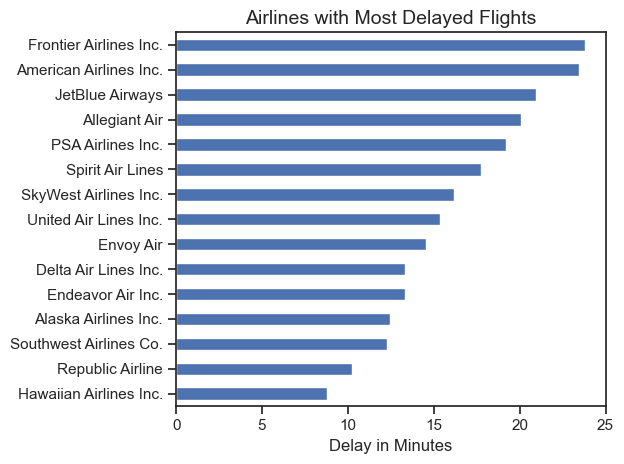

In [9]:
df_delay = df_clean.copy()
#clipping values that are in -ve as they represent early arrival
df_delay['delay_minutes'] = df_delay['arr_delay'].clip(lower=0)

most_delayed_flights = (df_delay.groupby(['cname'])['delay_minutes'].mean().sort_values(ascending=True))

most_delayed_flights.plot(kind='barh')
plt.title('Airlines with Most Delayed Flights', fontsize='14')
plt.ylabel('')
plt.xlabel('Delay in Minutes')
plt.tight_layout()
plt.show()

Frontier, American and JetBlue Airlines are the carriers with flights that are on average most delayed, with the top two carriers facing delays above 20 minutes on average. On the other hand, Republic and Hawaiian Airlines have less than 10 minutes of delay.

In [10]:
delay_cols = ['late_aircraft_delay','carrier_delay','nas_delay','weather_delay']
#creating a reasons for delay table for airlines
delay_reason= df_clean.groupby('cname')[delay_cols].mean()
delay_reason= delay_reason.transpose()
delay_reason

cname,Alaska Airlines Inc.,Allegiant Air,American Airlines Inc.,Delta Air Lines Inc.,Endeavor Air Inc.,Envoy Air,Frontier Airlines Inc.,Hawaiian Airlines Inc.,JetBlue Airways,PSA Airlines Inc.,Republic Airline,SkyWest Airlines Inc.,Southwest Airlines Co.,Spirit Air Lines,United Air Lines Inc.
late_aircraft_delay,4.353825,6.857725,10.656390,3.592508,4.917369,5.984723,12.083404,2.473386,7.502788,8.850871,3.044002,2.854485,5.699388,4.639035,5.846365
carrier_delay,3.152254,6.582459,7.235130,5.830624,3.803717,3.038085,5.852706,4.140532,7.749012,5.106290,2.476911,7.643052,3.058752,4.366985,4.164844
nas_delay,2.915779,3.388738,2.861517,2.290732,2.778404,2.748652,3.877095,0.218885,3.924306,2.373175,3.048729,2.251905,1.946632,6.928285,3.387645
weather_delay,0.426977,1.976290,1.193009,0.559111,0.830570,1.464232,0.443003,0.192029,0.486266,1.483316,0.723514,2.272563,0.266731,0.434334,0.762344


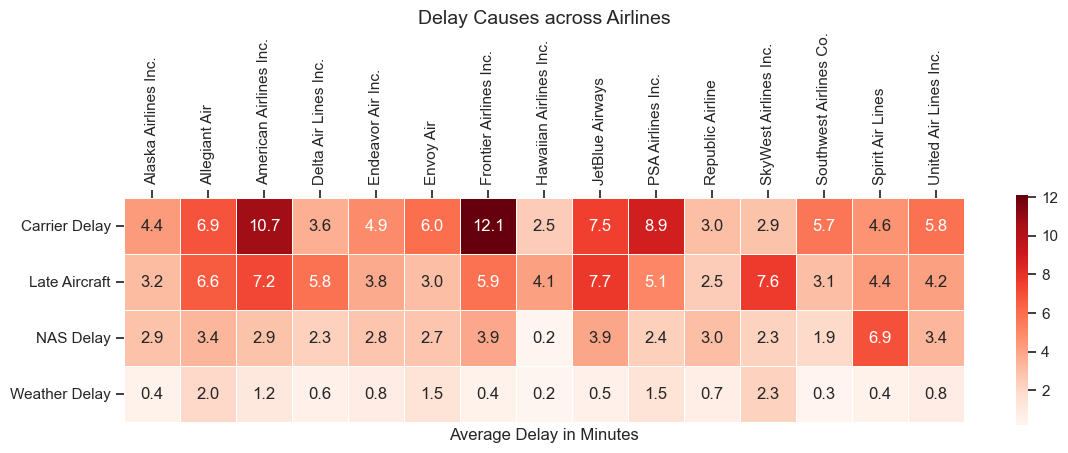

In [11]:
fig, ax= plt.subplots(figsize=(12,4))
sns.heatmap(delay_reason,annot=True, fmt='.1f',cmap= 'Reds', linewidths=0.5, ax=ax, square=True)
ax.xaxis.tick_top()
plt.xticks(rotation='vertical')
ax.set_yticklabels(['Carrier Delay','Late Aircraft','NAS Delay','Weather Delay'], rotation=0)
plt.title('Delay Causes across Airlines',  fontsize='14')
plt.xlabel('Average Delay in Minutes')
plt.ylabel('')

plt.tight_layout()
plt.show()


This heatmap represents the reasons for delay for each airlines with their average minutes of delays.Carrier delays and late aircraft delays are the main contributors to flight delays across most airlines, indicating that operational factors play a larger role than external causes. Weather delays remain relatively low across all carriers

In [12]:
most_delayed_routes = (df_delay.groupby(['origin', 'dest'])['delay_minutes'].mean().reset_index(name='avg_delay_in_mins').sort_values('avg_delay_in_mins', ascending=False).head(10))

most_delayed_routes = most_delayed_routes.round(1)

most_delayed_routes

,origin,dest,avg_delay_in_mins
3167,JFK,LGA,755.0
5828,SDF,SLC,365.0
2832,IAD,MSN,325.0
444,AVL,USA,310.0
6382,SRQ,IAH,299.6
2953,IAH,SDF,194.0
4382,MVY,CLT,191.6
3381,LAX,ATW,178.0
5219,PIE,VPS,178.0
321,ATW,LAX,172.5


The routes with the highest average delays include John F. Kennedy International Airport to LaGuardia Airport and Louisville Muhammad Ali International Airport to Salt Lake City International Airport, indicating congestion and operational pressure on both major hub and cross-country routes.

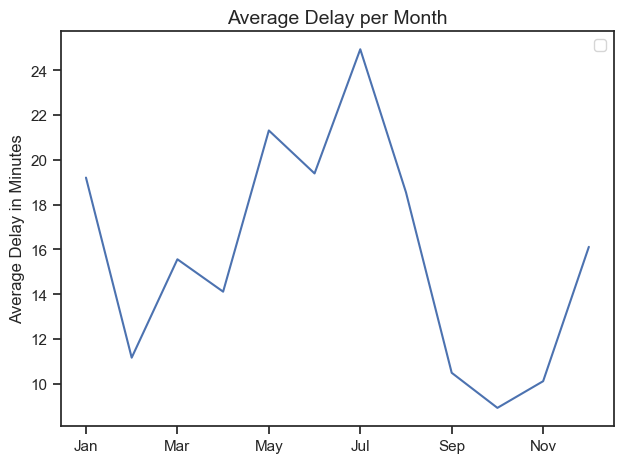

In [13]:
#adding flight month columns to the table
df_delay['fl_month']= df_delay['fl_date'].dt.strftime('%b')
df_delay['month_no']= df_delay['fl_date'].dt.month

worst_months = (df_delay.groupby(['fl_month', 'month_no'])['delay_minutes'].mean().sort_index(level='month_no'))
worst_months = worst_months.reset_index()

worst_months = worst_months.drop(columns='month_no')

worst_months = worst_months.set_index('fl_month')
worst_months.plot(kind='line')
plt.title('Average Delay per Month', fontsize=14)
plt.xlabel('')
plt.ylabel('Average Delay in Minutes')
plt.legend('')
plt.tight_layout()
plt.show()

The month of May and July have the highest trends of seasonal delays for flights, possibly indicating the volume of passengers and congestion caused from travellers on Summer break or taking summer vacation trips. Another peak arises during the holidays possibly as a result of high volume of congestion as well.

## 4. Southwest vs Industry

This section compares the performance of Southwest Airlines against the industry trends to evaluate its operational reliability. The comparison focuses on delay causes, seasonal delay patterns, flight outcome distribution (early, on-time, and late arrivals), and disruption metrics such as cancellations and diversions. This benchmark analysis helps determine whether Southwest performs above or below industry averages and highlights areas where its operational profile differs from other carriers.

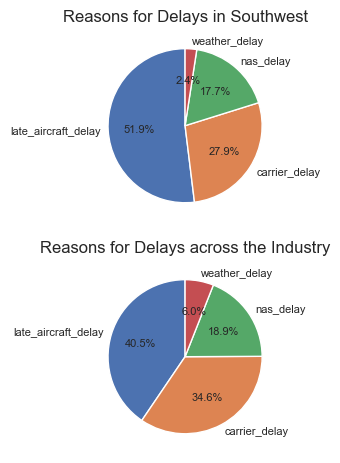

In [14]:
df_wn= df_clean[df_clean['op_unique_carrier']=='WN']

delay_wn= df_wn[delay_cols].sum()

delay_industry= df_clean[delay_cols].sum()

fig, ax= plt.subplots(2,1)

delay_wn.plot(kind='pie', ax=ax[0], startangle=90, autopct='%1.1f%%', labels=delay_cols, textprops={'fontsize':8})
ax[0].set_title('Reasons for Delays in Southwest')

delay_industry.plot(kind='pie', ax=ax[1], startangle=90, autopct='%1.1f%%', labels=delay_cols, textprops={'fontsize':8})
ax[1].set_title('Reasons for Delays across the Industry')

fig.tight_layout()


Southwest’s delays are mainly caused by late aircraft (about 52%), which is higher than the industry average, showing delays often carry over from earlier flights. Compared to the industry, Southwest has slightly fewer carrier and weather delays. This suggests Southwest’s delays are more affected by scheduling flow rather than operational or weather issues.

In [15]:
cancelled= (df_clean['cancelled'].sum())
total_flights= df_clean['fl_date'].count()

cancelled_rate=(cancelled/total_flights)*100


wn_cancelled= (df_wn['cancelled'].sum())
wn_flights= df_wn['fl_date'].count()

wn_cancelled_rate=(wn_cancelled/wn_flights)*100

print('SouthWest Flight Cancellation Rate :', "%.1f%%" %(wn_cancelled_rate))
print('Industry Flight Cancellation Rate :', "%.1f%%" %(cancelled_rate))


SouthWest Flight Cancellation Rate : 0.8%
Industry Flight Cancellation Rate : 1.4%


Southwest has significantly less airlines cancellations as opposed to industry average. This suggests that Southwest indicating their efficiency  and commitment of good service to customers.

In [16]:
diverted= (df_clean['diverted'].sum())
total_flights= df_clean['fl_date'].count()

diverted_rate=(diverted/total_flights)*100


wn_diverted= (df_wn['diverted'].sum())
wn_flights= df_wn['fl_date'].count()

wn_diverted_rate=(wn_diverted/wn_flights)*100

print('SouthWest Flight Diversion Rate :', "%.1f%%" %(wn_diverted_rate))
print('Industry Flight Diversion Rate :', "%.1f%%" %(diverted_rate))

SouthWest Flight Diversion Rate : 0.2%
Industry Flight Diversion Rate : 0.2%


Southwest has flight diversion rate that is on par with the industry with a mere 0.2% of total flights diverted.

In [17]:
#creating a new dataframe called compare
df_compare= df_clean.copy()
#adding flight months column
df_compare['fl_month']= df_compare['fl_date'].dt.strftime('%b')
df_compare['month_no']= df_compare['fl_date'].dt.month

#creating a new column called group with elements called Industry or Southwest for comparison
df_compare['group']= 'Industry'

df_compare.loc[df_compare['op_unique_carrier']=='WN', 'group']= 'Southwest'


In [18]:
#creating a pivot table with month and average delay reasons in minutes
df_compare_pivot= df_compare.pivot_table(index=('fl_month', 'month_no'), columns='group', values=delay_cols, aggfunc='mean')

df_compare_pivot= df_compare_pivot.sort_values('month_no')

df_compare_pivot= df_compare_pivot.reset_index()

df_compare_pivot.drop(columns='month_no', inplace=True)

df_compare_pivot.set_index('fl_month', inplace=True)

df_compare_pivot

C:\Users\lenovo\AppData\Local\Temp\ipykernel_10664\4196146793.py:8: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_compare_pivot.drop(columns='month_no', inplace=True)


carrier_delay           late_aircraft_delay           nas_delay  \
group         Industry Southwest            Industry Southwest  Industry   
fl_month                                                                   
Jan           6.324883  3.291553            7.056258  5.790075  3.356875   
Feb           3.992152  2.212486            3.745842  3.688718  2.282862   
Mar           5.006665  3.191392            5.928469  6.527333  3.223602   
Apr           4.715696  2.990828            5.329314  5.326367  2.807539   
May           6.406149  4.044189            8.291511  9.525609  4.258934   
Jun           6.749669  4.058304            7.506722  7.398023  3.493393   
Jul           9.403686  4.635982           10.192794  8.494257  4.037503   
Aug           6.440055  3.052975            7.160430  5.346000  3.803696   
Sep           4.047041  2.015121            3.746420  3.166257  1.833164   
Oct           3.751434  1.946340            2.976032  2.982021  1.357095   
Nov           3.757349  1.851569            3.358873  2.890195  2.211312   
Dec           5.649009  3.012995            5.939170  6.334618  2.902561   

                   weather_delay            
group    Southwest      Industry Southwest  
fl_month                                    
Jan       2.252554      2.194266  0.274688  
Feb       1.836608      0.640684  0.143470  
Mar       2.550394      0.717341  0.186195  
Apr       1.817016      0.790803  0.192247  
May       2.912234      1.597116  0.583864  
Jun       2.103758      1.262011  0.411559  
Jul       2.378496      1.202913  0.470065  
Aug       2.186762      1.168245  0.363527  
Sep       1.254004      0.539787  0.091302  
Oct       1.040369      0.319418  0.058817  
Nov       1.150891      0.595428  0.106376  
Dec       1.693970      1.325927  0.262660

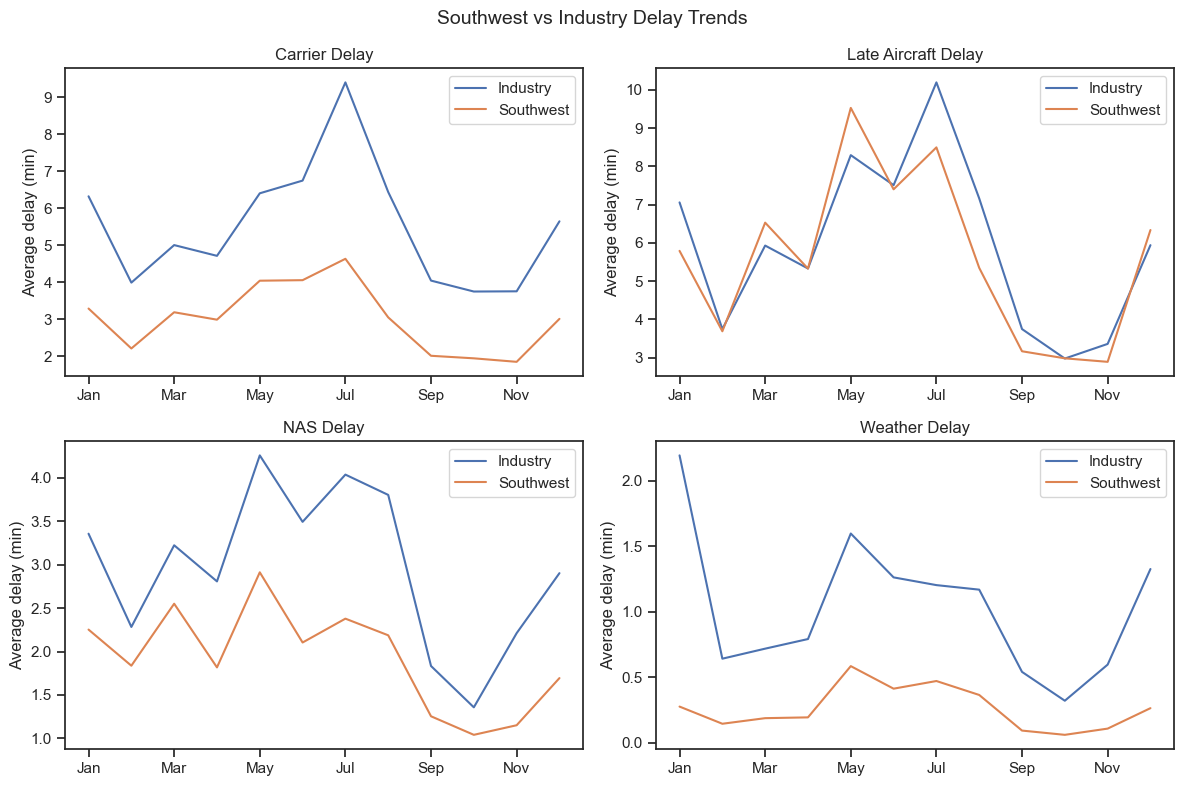

In [19]:
fig, ax= plt.subplots(2,2, figsize=(12,8))

delay_names = [
('carrier_delay','Carrier Delay'),
('late_aircraft_delay','Late Aircraft Delay'),
('nas_delay','NAS Delay'),
('weather_delay','Weather Delay')
]

for ax, (col,title) in zip(ax.flat, delay_names):

    df_compare_pivot[col].plot(ax=ax)

    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Average delay (min)')
    ax.legend()

plt.suptitle("Southwest vs Industry Delay Trends", fontsize=14)

plt.tight_layout()
plt.show()

Southwest generally shows lower average delays than the industry across all delay types throughout the year. Both Southwest and the industry experience peaks in delays during the summer months, especially for carrier and late aircraft delays. This applies to all delays except for weather delays which peak in winter months for the industry. 

The trends suggest that while Southwest follows similar seasonal patterns, it tends to maintain better delay performance compared to the industry average.

In [20]:
#the arrival delay column has values in negative and positive
def flight_status(delay):

    if delay < 0: #the negative values represent early arrival
        return 'Early Arrival'

    elif delay <= 15: #while the positive values indicate late or on time arrivals
        return 'On Time' #we are providing a 15 minute window for on time arrivals

    else:
        return 'Late Arrival'

df_compare['arrival'] = df_compare['arr_delay'].apply(flight_status)

In [21]:
#we are using the arrival criteria to compare industry vs WN
df_status= df_compare.groupby(['group','arrival']).size()

df_status= df_status.reset_index()

df_status= df_status.rename(columns={0: 'count'})

df_status_pivot=df_status.pivot_table(index='group', columns='arrival', values='count')

status_percent= df_status_pivot.apply(lambda x: x / x.sum() * 100, axis=1)

status_percent.map("{:,.2f}%".format)

arrival,Early Arrival,Late Arrival,On Time
group,,,
Industry,61.49%,21.62%,16.89%
Southwest,59.09%,20.67%,20.25%


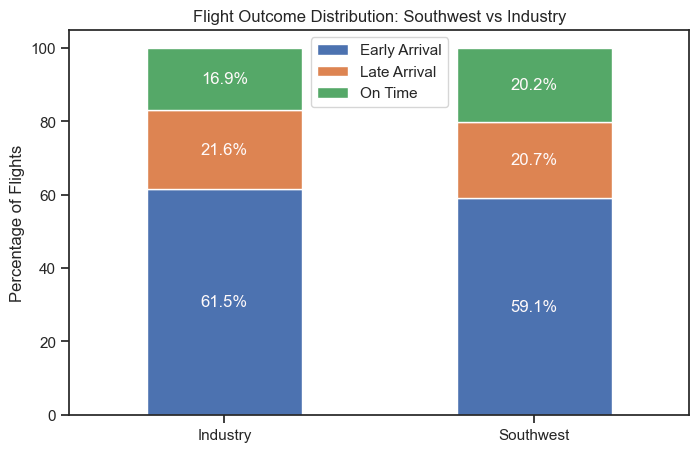

In [22]:
ax = status_percent.plot(kind='bar', stacked=True, figsize=(8,5))
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', color='snow')

plt.legend(loc='upper center')
plt.xlabel('')
plt.ylabel('Percentage of Flights')
plt.xticks(rotation='horizontal')
plt.title('Flight Outcome Distribution: Southwest vs Industry')

plt.show()

Southwest shows a slightly higher on-time arrival rate (20.2%) compared to the industry (16.9%), while maintaining a similar late arrival rate. The industry has a slightly higher proportion of early arrivals, but overall Southwest demonstrates slightly better schedule reliability through more on-time performance.

## 5. Key Findings

The analysis shows that flight delays across the US airline industry are primarily driven by operational factors, particularly late aircraft delays and carrier-related delays, rather than weather disruptions. Late aircraft delays consistently contribute the largest share of total delays, indicating that delays often propagate through airline schedules once disruptions begin.

When comparing Southwest to the industry, Southwest generally demonstrates lower average delays across most delay categories, although it shows a higher reliance on late aircraft delays compared to the industry average. This suggests that while Southwest manages controllable operational delays relatively well, its network may be more sensitive to delays carried over from previous flights.

Seasonal patterns also show that delays tend to peak during the summer months, likely due to higher travel demand and increased network congestion. Additionally, some regional airport routes show significantly higher average delays, indicating that smaller airports may have fewer recovery options when disruptions occur.

In conclusion, the results suggest that Southwest performs slightly better than the industry in terms of reliability, particularly in maintaining on-time performance, while industry delays are largely influenced by operational scheduling challenges rather than external factors like weather.